In [11]:
import os
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.models import inception_v3, Inception_V3_Weights
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix

from google.colab import drive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [12]:
import shutil, os
drive.mount('/content/drive')
drive_train = "/content/drive/MyDrive/PlantDoc2.0/train"
drive_test  = "/content/drive/MyDrive/PlantDoc2.0/test"

local_train = "/content/PlantDoc2.0/train"
local_test  = "/content/PlantDoc2.0/test"

if not os.path.exists(local_train):
    shutil.copytree(drive_train, local_train)

if not os.path.exists(local_test):
    shutil.copytree(drive_test, local_test)

train_dir = local_train
test_dir = local_test

print("Dataset copied to local runtime.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset copied to local runtime.


In [16]:
weights = Inception_V3_Weights.DEFAULT
transform = weights.transforms()   # 299x299 + ImageNet normalization

full_train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

train_size = int(0.875 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", len(full_train_dataset.classes))

Train: 2044
Validation: 292
Test: 236
Classes: 28


In [17]:
# ============================================================
# 3. Parsing Logic for Species and Disease
# ============================================================

def parse_class_name(class_name: str):
    """
    Robust parsing for PlantDoc dataset.

    Handles:
    - 'Apple Scab Leaf'
    - 'Tomato Early Blight'
    - 'Corn Rust'
    - 'Potato Healthy'
    """

    parts = class_name.strip().split()

    species_name = parts[0].capitalize()

    if len(parts) == 1:
        return species_name, "Healthy"

    if parts[-1].lower() == "leaf":
        disease_parts = parts[1:-1]
    else:
        disease_parts = parts[1:]

    if len(disease_parts) == 0:
        disease_name = "Healthy"
    else:
        disease_name = " ".join(disease_parts).title()

    return species_name, disease_name


def extract_label_mappings(class_names):
    """
    Build species and disease mappings with consistent ordering.
    """

    species_set = set()
    disease_set = set()
    valid_pairs = defaultdict(list)

    parsed_data = []

    for class_name in class_names:
        species_name, disease_name = parse_class_name(class_name)

        parsed_data.append((species_name, disease_name))
        species_set.add(species_name)
        disease_set.add(disease_name)

    species_list = sorted(list(species_set))
    disease_list = sorted(list(disease_set))

    species_to_idx = {name: idx for idx, name in enumerate(species_list)}
    disease_to_idx = {name: idx for idx, name in enumerate(disease_list)}

    for species_name, disease_name in parsed_data:
        s_idx = species_to_idx[species_name]
        d_idx = disease_to_idx[disease_name]

        if d_idx not in valid_pairs[s_idx]:
            valid_pairs[s_idx].append(d_idx)

    return species_to_idx, disease_to_idx, valid_pairs


def convert_imagefolder_labels_to_multioutput(
    labels,
    dataset_classes,
    species_to_idx,
    disease_to_idx
):
    """
    Convert ImageFolder labels into:
    - species labels
    - disease labels
    """

    species_labels = []
    disease_labels = []

    for label in labels.cpu().numpy():
        class_name = dataset_classes[label]
        species_name, disease_name = parse_class_name(class_name)

        species_labels.append(species_to_idx[species_name])
        disease_labels.append(disease_to_idx[disease_name])

    return (
        torch.tensor(species_labels, dtype=torch.long, device=device),
        torch.tensor(disease_labels, dtype=torch.long, device=device)
    )

In [18]:
# ============================================================
# 4. Build Label Mappings
# ============================================================

species_to_idx, disease_to_idx, valid_pairs = extract_label_mappings(
    full_train_dataset.classes
)

num_species = len(species_to_idx)
num_diseases = len(disease_to_idx)

idx_to_species = {v: k for k, v in species_to_idx.items()}
idx_to_disease = {v: k for k, v in disease_to_idx.items()}

print("Number of species:", num_species)
print("Number of diseases:", num_diseases)

print("\nSpecies mapping:")
for name, idx in species_to_idx.items():
    print(idx, name)

print("\nDisease mapping:")
for name, idx in disease_to_idx.items():
    print(idx, name)

print("\nValid species-disease pairs:")
for s_idx, d_indices in valid_pairs.items():
    print(idx_to_species[s_idx], "->", [idx_to_disease[d] for d in d_indices])

Number of species: 13
Number of diseases: 17

Species mapping:
0 Apple
1 Bell_pepper
2 Blueberry
3 Cherry
4 Corn
5 Grape
6 Peach
7 Potato
8 Raspberry
9 Soyabean
10 Squash
11 Strawberry
12 Tomato

Disease mapping:
0 Early Blight
1 Gray Leaf Spot
2 Healthy
3 Leaf Bacterial Spot
4 Leaf Black Rot
5 Leaf Blight
6 Leaf Early Blight
7 Leaf Late Blight
8 Leaf Mosaic Virus
9 Leaf Spot
10 Leaf Yellow Virus
11 Mold
12 Powdery Mildew
13 Rust
14 Scab
15 Septoria Leaf Spot
16 Two Spotted Spider Mites

Valid species-disease pairs:
Apple -> ['Scab', 'Healthy', 'Rust']
Bell_pepper -> ['Healthy', 'Leaf Spot']
Blueberry -> ['Healthy']
Cherry -> ['Healthy']
Corn -> ['Gray Leaf Spot', 'Leaf Blight', 'Rust']
Peach -> ['Healthy']
Potato -> ['Leaf Early Blight', 'Leaf Late Blight']
Raspberry -> ['Healthy']
Soyabean -> ['Healthy']
Squash -> ['Powdery Mildew']
Strawberry -> ['Healthy']
Tomato -> ['Early Blight', 'Septoria Leaf Spot', 'Healthy', 'Leaf Bacterial Spot', 'Leaf Late Blight', 'Leaf Mosaic Virus', 'Le

In [19]:
# ============================================================
# 5. Build Valid Pair Mask
# ============================================================

def build_valid_pair_mask(valid_pairs, num_species, num_diseases, device):
    mask = torch.zeros(
        (num_species, num_diseases),
        dtype=torch.float32,
        device=device
    )

    for species_idx, disease_indices in valid_pairs.items():
        for disease_idx in disease_indices:
            mask[species_idx, disease_idx] = 1.0

    return mask


valid_pair_mask = build_valid_pair_mask(
    valid_pairs,
    num_species,
    num_diseases,
    device
)

print("Valid pair mask shape:", valid_pair_mask.shape)

Valid pair mask shape: torch.Size([13, 17])


In [20]:
# ============================================================
# 6. InceptionV3 Multi-Output Model
# ============================================================

class InceptionV3JointSemanticModel(nn.Module):
    def __init__(self, num_species, num_diseases, freeze_backbone=False):
        super().__init__()

        self.backbone = inception_v3(
            weights=Inception_V3_Weights.DEFAULT,
            aux_logits=True
        )

        self.backbone.aux_logits = False
        self.backbone.AuxLogits = None

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.dropout = nn.Dropout(0.4)

        self.species_head = nn.Linear(in_features, num_species)
        self.disease_head = nn.Linear(in_features, num_diseases)

    def forward(self, x):
        features = self.backbone(x)

        features = self.dropout(features)

        species_logits = self.species_head(features)
        disease_logits = self.disease_head(features)

        return species_logits, disease_logits


model = InceptionV3JointSemanticModel(
    num_species=num_species,
    num_diseases=num_diseases,
    freeze_backbone=False
).to(device)

print(model)

InceptionV3JointSemanticModel(
  (backbone): Inception3(
    (Conv2d_1a_3x3): BasicConv2d(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2a_3x3): BasicConv2d(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (Conv2d_2b_3x3): BasicConv2d(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (Conv2d_3b_1x1): BasicConv2d(
      (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (

In [21]:
# ============================================================
# 7. Joint Semantic Loss
# ============================================================

criterion_species = nn.CrossEntropyLoss()
criterion_disease = nn.CrossEntropyLoss()


def exactly_one_semantic_loss(logits):
    """
    Encourages exactly one class to be active.
    """

    probs = torch.softmax(logits, dim=1)

    one_minus_probs = 1 - probs
    batch_losses = []

    for i in range(probs.size(1)):
        selected_prob = probs[:, i]

        other_probs = torch.cat(
            [one_minus_probs[:, :i], one_minus_probs[:, i + 1:]],
            dim=1
        )

        exact_one_prob = selected_prob * torch.prod(other_probs, dim=1)
        batch_losses.append(exact_one_prob)

    total_exact_one_prob = torch.stack(batch_losses, dim=1).sum(dim=1)

    loss = -torch.log(total_exact_one_prob + 1e-8).mean()

    return loss


def cross_relation_semantic_loss(species_logits, disease_logits, valid_pair_mask):
    """
    Penalises invalid species-disease combinations.
    """

    species_probs = torch.softmax(species_logits, dim=1)
    disease_probs = torch.softmax(disease_logits, dim=1)

    joint_probs = species_probs.unsqueeze(2) * disease_probs.unsqueeze(1)

    valid_probability = (
        joint_probs * valid_pair_mask.unsqueeze(0)
    ).sum(dim=(1, 2))

    loss = -torch.log(valid_probability + 1e-8).mean()

    return loss


def compute_joint_semantic_loss(
    species_logits,
    disease_logits,
    species_labels,
    disease_labels,
    lambda_semantic=0.1,
    lambda_cross=0.2
):
    species_ce = criterion_species(species_logits, species_labels)
    disease_ce = criterion_disease(disease_logits, disease_labels)

    species_semantic = exactly_one_semantic_loss(species_logits)
    disease_semantic = exactly_one_semantic_loss(disease_logits)

    cross_semantic = cross_relation_semantic_loss(
        species_logits,
        disease_logits,
        valid_pair_mask
    )

    total_loss = (
        species_ce
        + disease_ce
        + lambda_semantic * (species_semantic + disease_semantic)
        + lambda_cross * cross_semantic
    )

    return total_loss, {
        "species_ce": species_ce.item(),
        "disease_ce": disease_ce.item(),
        "species_semantic": species_semantic.item(),
        "disease_semantic": disease_semantic.item(),
        "cross_semantic": cross_semantic.item(),
        "total_loss": total_loss.item()
    }

In [22]:
# ============================================================
# 8. Optimizer, Scheduler, AMP
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

USE_AMP = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("AMP enabled:", USE_AMP)

AMP enabled: True


In [23]:
# ============================================================
# 9. Training and Evaluation Epoch Function
# ============================================================

def run_one_epoch(model, loader, optimizer=None, base_dataset=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    all_species_true = []
    all_species_pred = []

    all_disease_true = []
    all_disease_pred = []

    both_correct = []

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            species_labels, disease_labels = convert_imagefolder_labels_to_multioutput(
                labels,
                base_dataset.classes,
                species_to_idx,
                disease_to_idx
            )

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                "cuda",
                enabled=USE_AMP
            ):
                species_logits, disease_logits = model(images)

                loss, loss_parts = compute_joint_semantic_loss(
                    species_logits,
                    disease_logits,
                    species_labels,
                    disease_labels
                )

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()

            species_pred = torch.argmax(species_logits, dim=1)
            disease_pred = torch.argmax(disease_logits, dim=1)

            all_species_true.extend(species_labels.cpu().numpy())
            all_species_pred.extend(species_pred.cpu().numpy())

            all_disease_true.extend(disease_labels.cpu().numpy())
            all_disease_pred.extend(disease_pred.cpu().numpy())

            both_correct.extend(
                ((species_pred == species_labels) & (disease_pred == disease_labels))
                .cpu()
                .numpy()
            )

    metrics = {
        "loss": total_loss / len(loader),
        "species_acc": accuracy_score(all_species_true, all_species_pred),
        "disease_acc": accuracy_score(all_disease_true, all_disease_pred),
        "both_acc": float(np.mean(both_correct)),
        "species_f1": f1_score(
            all_species_true,
            all_species_pred,
            average="macro",
            zero_division=0
        ),
        "disease_f1": f1_score(
            all_disease_true,
            all_disease_pred,
            average="macro",
            zero_division=0
        )
    }

    return metrics

In [24]:
# ============================================================
# 10. Training Loop with Checkpoint Saving
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/Models"
os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_PATH = os.path.join(
    SAVE_DIR,
    "inceptionv3_joint_semantic_loss_best.pth"
)

LOG_PATH = os.path.join(
    SAVE_DIR,
    "inceptionv3_joint_semantic_loss_log.csv"
)

num_epochs = 30
best_val_loss = np.inf
start_epoch = 0

if os.path.exists(SAVE_PATH):
    checkpoint = torch.load(SAVE_PATH, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"]
    best_val_loss = checkpoint.get("best_val_loss", np.inf)

    print(f"Resumed from epoch {start_epoch}")
else:
    print("No checkpoint found. Starting fresh training.")


write_header = not os.path.exists(LOG_PATH)

with open(LOG_PATH, "a", newline="") as file:
    writer = csv.writer(file)

    if write_header:
        writer.writerow([
            "epoch",
            "train_loss",
            "val_loss",
            "train_species_acc",
            "train_disease_acc",
            "train_both_acc",
            "val_species_acc",
            "val_disease_acc",
            "val_both_acc",
            "train_species_f1",
            "train_disease_f1",
            "val_species_f1",
            "val_disease_f1"
        ])

    for epoch in range(start_epoch, num_epochs):
        train_metrics = run_one_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            base_dataset=full_train_dataset
        )

        val_metrics = run_one_epoch(
            model,
            val_loader,
            optimizer=None,
            base_dataset=full_train_dataset
        )

        scheduler.step(val_metrics["loss"])

        writer.writerow([
            epoch + 1,
            train_metrics["loss"],
            val_metrics["loss"],
            train_metrics["species_acc"],
            train_metrics["disease_acc"],
            train_metrics["both_acc"],
            val_metrics["species_acc"],
            val_metrics["disease_acc"],
            val_metrics["both_acc"],
            train_metrics["species_f1"],
            train_metrics["disease_f1"],
            val_metrics["species_f1"],
            val_metrics["disease_f1"]
        ])

        file.flush()

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Species Acc: {val_metrics['species_acc']:.4f} | "
            f"Val Disease Acc: {val_metrics['disease_acc']:.4f} | "
            f"Val Both Acc: {val_metrics['both_acc']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]

            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_loss": best_val_loss,
                "species_to_idx": species_to_idx,
                "disease_to_idx": disease_to_idx,
                "valid_pairs": dict(valid_pairs),
                "idx_to_species": idx_to_species,
                "idx_to_disease": idx_to_disease
            }, SAVE_PATH)

            print("Saved best InceptionV3 Joint Semantic Loss model")

No checkpoint found. Starting fresh training.
Epoch [1/30] | Train Loss: 4.1623 | Val Loss: 2.5827 | Val Species Acc: 0.6712 | Val Disease Acc: 0.6062 | Val Both Acc: 0.4384
Saved best InceptionV3 Joint Semantic Loss model
Epoch [2/30] | Train Loss: 2.2735 | Val Loss: 1.7672 | Val Species Acc: 0.7740 | Val Disease Acc: 0.6712 | Val Both Acc: 0.5308
Saved best InceptionV3 Joint Semantic Loss model
Epoch [3/30] | Train Loss: 1.3775 | Val Loss: 1.4544 | Val Species Acc: 0.8390 | Val Disease Acc: 0.6884 | Val Both Acc: 0.5993
Saved best InceptionV3 Joint Semantic Loss model
Epoch [4/30] | Train Loss: 0.8510 | Val Loss: 1.3382 | Val Species Acc: 0.8801 | Val Disease Acc: 0.7226 | Val Both Acc: 0.6610
Saved best InceptionV3 Joint Semantic Loss model
Epoch [5/30] | Train Loss: 0.5557 | Val Loss: 1.3004 | Val Species Acc: 0.8527 | Val Disease Acc: 0.7226 | Val Both Acc: 0.6507
Saved best InceptionV3 Joint Semantic Loss model
Epoch [6/30] | Train Loss: 0.3771 | Val Loss: 1.3477 | Val Species Ac

Loaded best checkpoint for testing.


,Task,Accuracy (%),Precision,Recall,F1-score
0,Species Prediction,79.661017,0.793854,0.796610,0.792130
1,Disease Prediction,66.949153,0.667962,0.669492,0.658413
2,Both Correct,57.203390,NaN,NaN,NaN


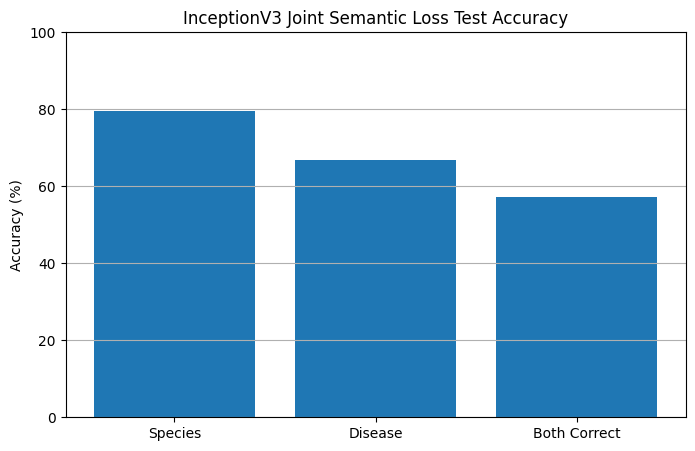

In [25]:
# ============================================================
# 11. Test Evaluation
# ============================================================

def evaluate_model(model, loader, base_dataset):
    model.eval()

    all_species_true = []
    all_species_pred = []

    all_disease_true = []
    all_disease_pred = []

    both_correct = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            species_labels, disease_labels = convert_imagefolder_labels_to_multioutput(
                labels,
                base_dataset.classes,
                species_to_idx,
                disease_to_idx
            )

            species_logits, disease_logits = model(images)

            species_pred = torch.argmax(species_logits, dim=1)
            disease_pred = torch.argmax(disease_logits, dim=1)

            all_species_true.extend(species_labels.cpu().numpy())
            all_species_pred.extend(species_pred.cpu().numpy())

            all_disease_true.extend(disease_labels.cpu().numpy())
            all_disease_pred.extend(disease_pred.cpu().numpy())

            both_correct.extend(
                ((species_pred == species_labels) & (disease_pred == disease_labels))
                .cpu()
                .numpy()
            )

    species_acc = accuracy_score(all_species_true, all_species_pred) * 100
    disease_acc = accuracy_score(all_disease_true, all_disease_pred) * 100
    both_acc = float(np.mean(both_correct)) * 100

    species_precision, species_recall, species_f1, _ = precision_recall_fscore_support(
        all_species_true,
        all_species_pred,
        average="weighted",
        zero_division=0
    )

    disease_precision, disease_recall, disease_f1, _ = precision_recall_fscore_support(
        all_disease_true,
        all_disease_pred,
        average="weighted",
        zero_division=0
    )

    results = pd.DataFrame({
        "Task": [
            "Species Prediction",
            "Disease Prediction",
            "Both Correct"
        ],
        "Accuracy (%)": [
            species_acc,
            disease_acc,
            both_acc
        ],
        "Precision": [
            species_precision,
            disease_precision,
            np.nan
        ],
        "Recall": [
            species_recall,
            disease_recall,
            np.nan
        ],
        "F1-score": [
            species_f1,
            disease_f1,
            np.nan
        ]
    })

    display(results)

    plt.figure(figsize=(8, 5))
    plt.bar(
        ["Species", "Disease", "Both Correct"],
        [species_acc, disease_acc, both_acc]
    )
    plt.ylabel("Accuracy (%)")
    plt.title("InceptionV3 Joint Semantic Loss Test Accuracy")
    plt.ylim(0, 100)
    plt.grid(axis="y")
    plt.show()

    return results


if os.path.exists(SAVE_PATH):
    checkpoint = torch.load(SAVE_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded best checkpoint for testing.")

test_results = evaluate_model(
    model,
    test_loader,
    test_dataset
)

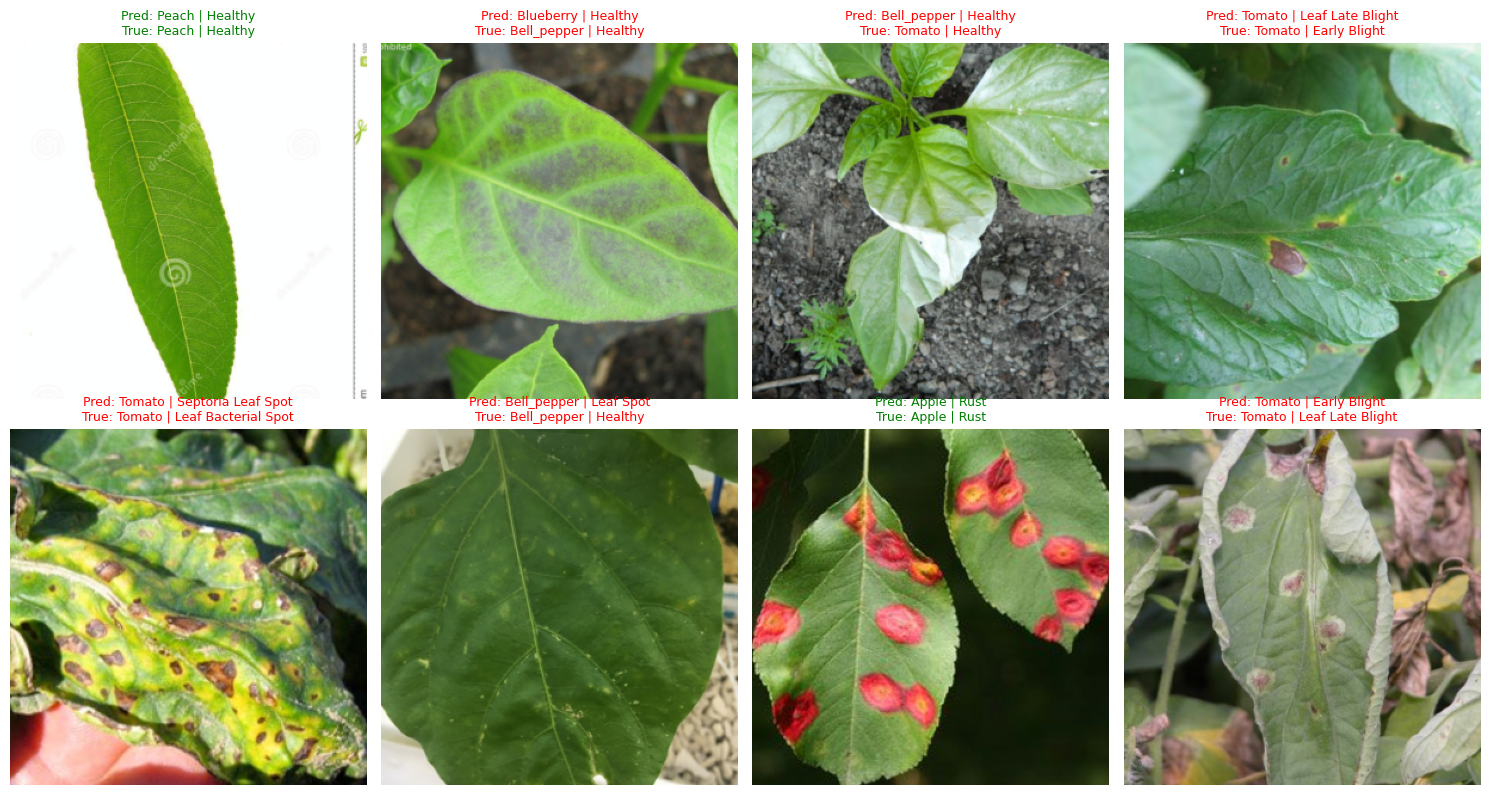

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def show_predictions(model, dataset, num_samples=8):
    model.eval()

    indices = np.random.choice(len(dataset), num_samples, replace=False)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        input_img = image.unsqueeze(0).to(device)

        with torch.no_grad():
            species_logits, disease_logits = model(input_img)

        # Predictions
        sp_pred = torch.argmax(species_logits, dim=1).item()
        dis_pred = torch.argmax(disease_logits, dim=1).item()

        # Ground truth
        class_name = dataset.classes[label]
        sp_true_name, dis_true_name = parse_class_name(class_name)

        # Predicted names
        sp_pred_name = idx_to_species[sp_pred]
        dis_pred_name = idx_to_disease[dis_pred]

        # Convert tensor image to displayable format
        img = image.cpu().numpy().transpose(1, 2, 0)

        # Denormalize (IMPORTANT for Inception)
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(2, num_samples // 2, i + 1)
        plt.imshow(img)
        plt.axis("off")

        # Color: green if correct, red if wrong
        correct = (sp_pred_name == sp_true_name) and (dis_pred_name == dis_true_name)
        color = "green" if correct else "red"

        plt.title(
            f"Pred: {sp_pred_name} | {dis_pred_name}\n"
            f"True: {sp_true_name} | {dis_true_name}",
            fontsize=9,
            color=color
        )

    plt.tight_layout()
    plt.show()
show_predictions(model, test_dataset, num_samples=8)

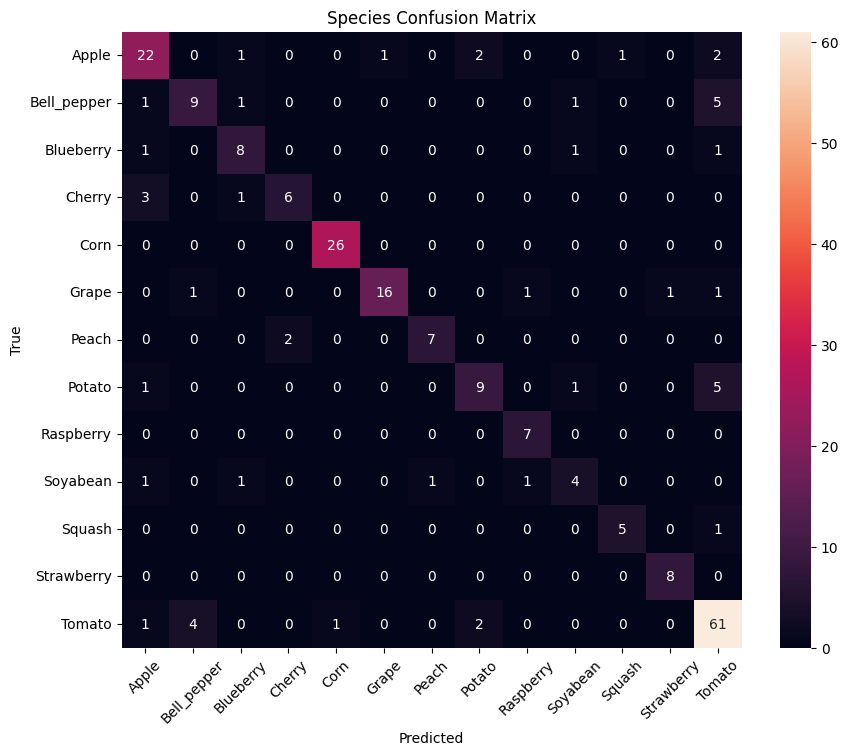

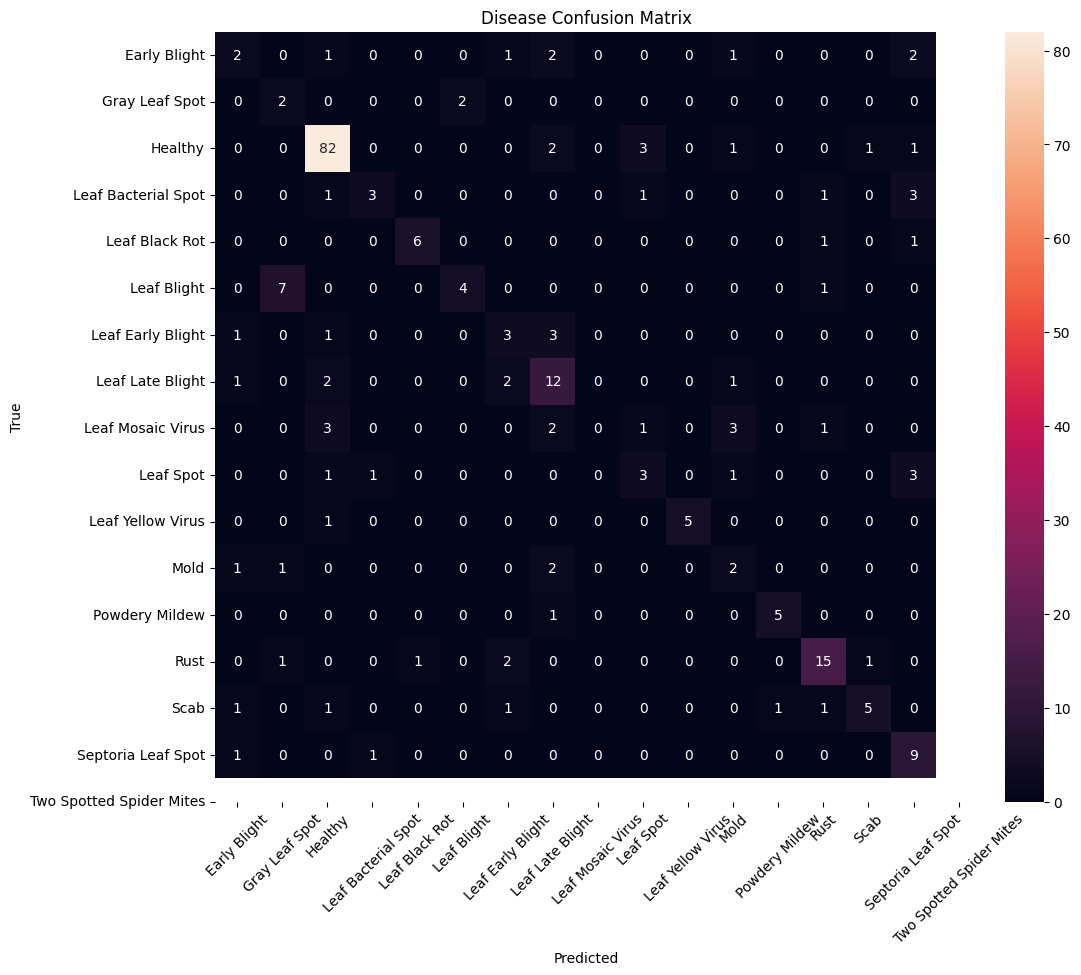

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrices(model, loader, dataset):
    model.eval()

    all_species_true = []
    all_species_pred = []

    all_disease_true = []
    all_disease_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            sp_labels, dis_labels = convert_imagefolder_labels_to_multioutput(
                labels,
                dataset.classes,
                species_to_idx,
                disease_to_idx
            )

            sp_logits, dis_logits = model(images)

            sp_pred = torch.argmax(sp_logits, dim=1)
            dis_pred = torch.argmax(dis_logits, dim=1)

            all_species_true.extend(sp_labels.cpu().numpy())
            all_species_pred.extend(sp_pred.cpu().numpy())

            all_disease_true.extend(dis_labels.cpu().numpy())
            all_disease_pred.extend(dis_pred.cpu().numpy())

    # Convert to arrays
    all_species_true = np.array(all_species_true)
    all_species_pred = np.array(all_species_pred)

    all_disease_true = np.array(all_disease_true)
    all_disease_pred = np.array(all_disease_pred)

    # Compute confusion matrices
    species_cm = confusion_matrix(all_species_true, all_species_pred)
    disease_cm = confusion_matrix(all_disease_true, all_disease_pred)

    # Plot Species Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        species_cm,
        annot=True,
        fmt="d",
        xticklabels=[idx_to_species[i] for i in range(len(idx_to_species))],
        yticklabels=[idx_to_species[i] for i in range(len(idx_to_species))]
    )
    plt.title("Species Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

    # Plot Disease Confusion Matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        disease_cm,
        annot=True,
        fmt="d",
        xticklabels=[idx_to_disease[i] for i in range(len(idx_to_disease))],
        yticklabels=[idx_to_disease[i] for i in range(len(idx_to_disease))]
    )
    plt.title("Disease Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

plot_confusion_matrices(model, test_loader, test_dataset)

Too many classes (27), showing first 20


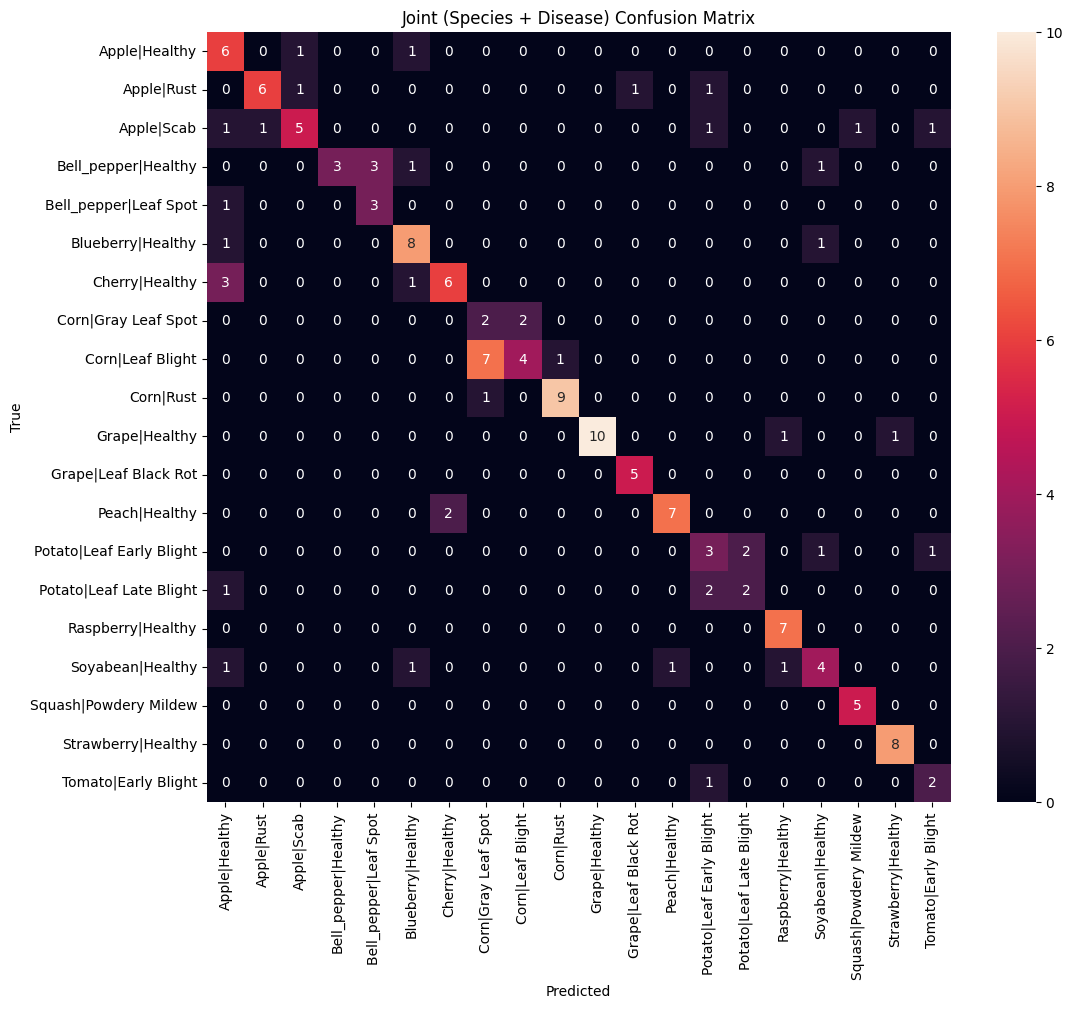

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_joint_confusion_matrix(model, loader, dataset, max_classes=20):
    model.eval()

    joint_true = []
    joint_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            sp_labels, dis_labels = convert_imagefolder_labels_to_multioutput(
                labels,
                dataset.classes,
                species_to_idx,
                disease_to_idx
            )

            sp_logits, dis_logits = model(images)

            sp_pred = torch.argmax(sp_logits, dim=1)
            dis_pred = torch.argmax(dis_logits, dim=1)

            # Create joint labels
            for i in range(len(sp_labels)):
                true_label = (
                    idx_to_species[sp_labels[i].item()],
                    idx_to_disease[dis_labels[i].item()]
                )

                pred_label = (
                    idx_to_species[sp_pred[i].item()],
                    idx_to_disease[dis_pred[i].item()]
                )

                joint_true.append(true_label)
                joint_pred.append(pred_label)

    # Convert to string labels
    joint_true_str = [f"{s}|{d}" for s, d in joint_true]
    joint_pred_str = [f"{s}|{d}" for s, d in joint_pred]

    # Get unique labels (limit for readability)
    unique_labels = list(set(joint_true_str))
    unique_labels = sorted(unique_labels)

    if len(unique_labels) > max_classes:
        print(f"Too many classes ({len(unique_labels)}), showing first {max_classes}")
        unique_labels = unique_labels[:max_classes]

    cm = confusion_matrix(joint_true_str, joint_pred_str, labels=unique_labels)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=unique_labels,
        yticklabels=unique_labels
    )

    plt.title("Joint (Species + Disease) Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()
plot_joint_confusion_matrix(model, test_loader, test_dataset)

,epoch,train_loss,val_loss,train_species_acc,train_disease_acc,train_both_acc,val_species_acc,val_disease_acc,val_both_acc,train_species_f1,train_disease_f1,val_species_f1,val_disease_f1
25,26,0.045199,1.553445,0.997065,0.995108,0.995108,0.866438,0.722603,0.664384,0.998322,0.993822,0.857411,0.589749
26,27,0.037345,1.502258,0.996575,0.997554,0.996086,0.873288,0.719178,0.667808,0.997767,0.997130,0.865917,0.602203
27,28,0.037312,1.514953,0.996575,0.996575,0.995108,0.876712,0.719178,0.671233,0.998054,0.994934,0.874167,0.597516
28,29,0.039778,1.523732,0.997554,0.997554,0.996086,0.876712,0.715753,0.667808,0.998599,0.996768,0.871651,0.581417
29,30,0.041909,1.508379,0.996575,0.998532,0.995597,0.876712,0.712329,0.671233,0.996825,0.998154,0.872747,0.583127


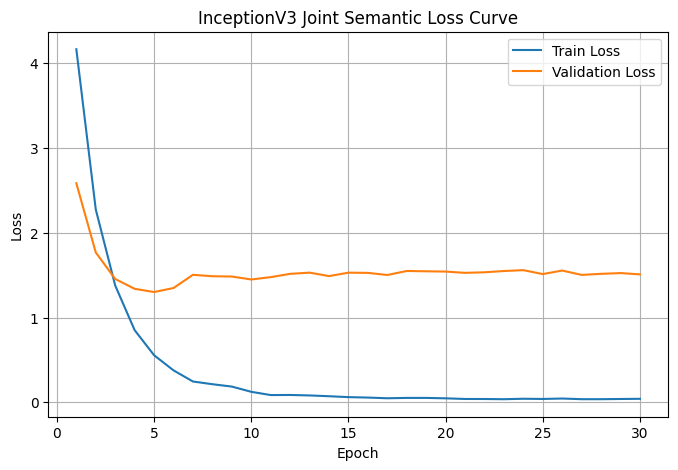

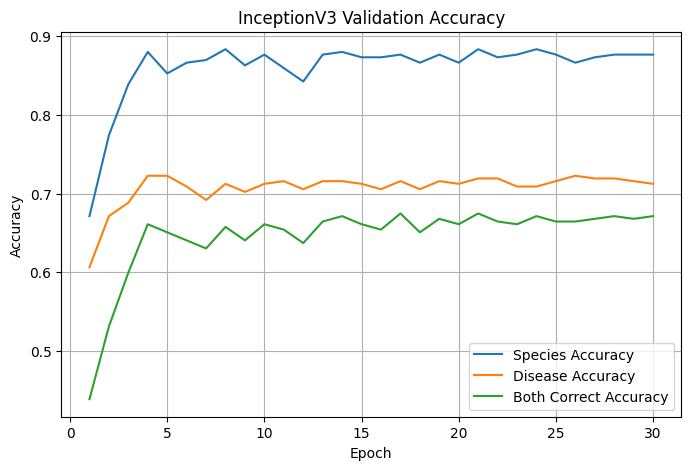

In [27]:
# ============================================================
# 12. Plot Training Curves
# ============================================================

if os.path.exists(LOG_PATH):
    log_df = pd.read_csv(LOG_PATH)

    display(log_df.tail())

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["train_loss"], label="Train Loss")
    plt.plot(log_df["epoch"], log_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("InceptionV3 Joint Semantic Loss Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["epoch"], log_df["val_species_acc"], label="Species Accuracy")
    plt.plot(log_df["epoch"], log_df["val_disease_acc"], label="Disease Accuracy")
    plt.plot(log_df["epoch"], log_df["val_both_acc"], label="Both Correct Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("InceptionV3 Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("No log file found yet.")